# Heat Capacity Ratio of Gases via Adiabatic Expansion


The heat capacity ratio, $$ \gamma = \dfrac{C_{p,m}}{C_{v,m}} $$ can be determined straightforwardly by monitoring the pressure from an adiabatic expansion, followed by the system coming to equilibrium at constant volume. The technique of determining $\gamma$ from an adiabatic expansion dates to the early 1800s via the [Clément-Desormes experiment](https://phys.libretexts.org/Bookshelves/Thermodynamics_and_Statistical_Mechanics/Heat_and_Thermodynamics_(Tatum)/08%3A_Heat_Capacity_and_the_Expansion_of_Gases/8.05%3A_The_Clement-Desormes_Experiment). Practically, this is done by pressurizing a large vessel (carboy) to roughly 5-10\% above atmospheric pressure. After thermal equilibrium is reached, the vessel is opened and the gas expands quickly against atmospheric pressure. The vessel is closed again and the gas, cooled by the expansion, returns to ambient temperature and to a pressure higher then atmospheric.

<div>
  <center> <img width="500" src="https://github.com/act-cms/adiabatic-expansion-data-analysis/blob/dev/02_adiabatic-expansion/Figures/Adiabatic_Carboy.png?raw=True"> </center>
</div>

The experimental set-up is given the above figure. It consists of a 5-gallon glass carboy fitted with a \#7 stopper with three holes. As shown in the figure, the three-hole stopper allows for a gas inlet, gas outlet and pressure sensor, and a port for a temperature sensor. The configuration above indicates that the carboy will be filled by gas heavier than the gas currently in the carboy. Heavy gas enters at the bottom of the carboy and pushes the lighter gas out. In the case where a lighter gas is introduced, then the gas source will be attached to the valve B side and the valve A side will be the outlet.

Pressure will be monitored with a Vernier Biological Gas Pressure Sensor (BGP-DIN). Temperature will be monitored with a Vernier Surface Temperature Sensor (STS-BTA). The BGP-DIN pressure sensor is calibrated over the range 0.75 to 1.54 atm.

By monitoring pressure and temperature simultaneously, there is insight into the measured pressures ($p_1$, $p_2$, $p_3$) through dynamical measurements.

<div>
  <center> <img width="500" src="https://github.com/act-cms/adiabatic-expansion-data-analysis/blob/dev/02_adiabatic-expansion/Figures/Pressure-Temp_v_Time.png?raw=True"> </center>
</div>

:::{admonition} Overview
- Data Filtering and Slicing.
- Extracting information from a text file.
- Analyze PSI4 calculations in Google Colab.
- Constructing Python functions to repeat a task.
:::

## Import Packages

In [1]:
import numpy as np # Import numerical analysis
import os,sys,re # Import regex
import pandas as pd # DataFrame analysis
from glob import glob # A Python utility that uses wildcard patterns (like *.txt) to automatically find and list matching files in a folder.

#Spectra fitting - scipy
from scipy import interpolate
import scipy.optimize
from scipy import signal
from scipy.signal import savgol_filter
from scipy import stats

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
cmap = matplotlib.colormaps["rainbow"]
matplotlib.rcParams.update({'font.size': 16})

# Insert a progress bar to show the progress of the script
from tqdm import tqdm  # Existing tqdm import
from tqdm.notebook import tqdm, tnrange, trange

#Quizzes
from IPython.display import display, HTML

%pip install "jupyterquiz"
from jupyterquiz import display_quiz

import sys
sys.path.append('..')  # Add parent directory to path
import quiz_utils      # Now you can import it directly

Note: you may need to restart the kernel to use updated packages.


# Part 1. Work with a single trial

Once we get the code working for a single data set, we can move to [Part 2](#scrollTo=8GtN79tGBIq7&line=5&uniqifier=1) to create a function to automate the rest of the data analysis.

In [3]:
# Import your data here
# Save each trial as a new variable.
Ar_Trial1=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Argon_Trial1')
Ar_Trial2=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Argon_Trial2')
N2_Trial1=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Nitrogen_Trial1')
N2_Trial2=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Nitrogen_Trial2')
C3H8_Trial1=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Propane_Trial1')
C3H8_Trial2=pd.read_excel('Sample-Data/Adiabatic_SampleData.xlsx',sheet_name='Propane_Trial2')

:::{hint} 🐍 Note
:icon: false
For the first part of the notebook, only use the first trial for Ar. We want to get the code working for a singular data set first, then we will worry about the other data.
:::

:::{warning} ✏️ Exercise: Filter Pressures Above 110 kPa
:icon: false
For your DataFrame, use data slices to visualize all the pressure measurements > 110 and see what the result looks like in a plot. Your plot should contain:

- The original data for one pressure sensor.
- The filtered data with pressure > 110 (for one pressure sensor).
- Axes labels.
:::

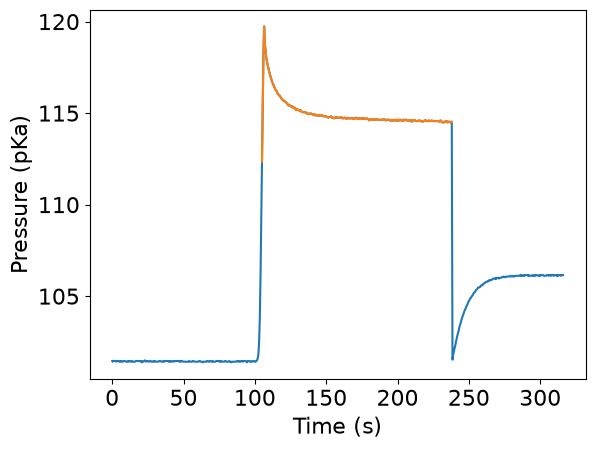

In [4]:
p_110=Ar_Trial1[Ar_Trial1['Pressure1']>110]

plt.plot(Ar_Trial1.Time,Ar_Trial1.Pressure1)
plt.plot(p_110.Time,p_110.Pressure1)
plt.ylabel('Pressure (pKa)')
plt.xlabel('Time (s)')
plt.show()

:::{danger} ❓ Question 1
:icon: false
Think about how we are going to calculate $p_1$, $p_2$, and $p_3$ by filtering our data. The criteria for each pressure is as follows:

- $p_1$ is the ten data points right before the pressure drop.
- $p_2$ is the singular pressure value immediately following the drop.
- $p_3$ is the last ten data points.

At this stage, focus on the process and include your thoughts in the answer cell below. We will figure out the syntax in the next section.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> _Type your answer here!_
::::::

## 1.1 Calculate $p_1$, $p_2$, $p_3$

:::{danger} ❓ Question 2
:icon: false
How do we figure out where to select points?

If we are looking for a point at the edge of the proverbial cliff, how do you think we can calculate where the edge of the cliff is?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> _Type your answer here!_
::::::

:::{hint} 🐍 Note
:icon: false

There are a few functions that accomplish this. We will use the numpy difference (np.diff) function, which calculates the difference between adjacent indices in a row/column (specify axis=0 or axis=1).

`np.diff()`


**Use the np.diff function to calculate the difference between each value.**

Store this array as a DataFrame, and then save that variable.
:::

In [5]:
p1_diff=np.diff(Ar_Trial1.Pressure1)
p1_diff

array([ -0.038,   0.038,   0.   ,   0.   ,   0.   ,  -0.038,   0.038,
         0.   ,   0.   ,  -0.038,   0.038,  -0.038,   0.038,  -0.038,
         0.   ,   0.038,   0.   ,   0.   ,  -0.038,   0.   ,   0.   ,
         0.038,  -0.038,   0.038,   0.   ,  -0.038,   0.   ,   0.038,
        -0.038,   0.   ,   0.   ,   0.   ,   0.038,   0.   ,   0.   ,
         0.   ,   0.   ,   0.   ,   0.   ,   0.   ,  -0.075,   0.075,
        -0.038,   0.   ,   0.038,   0.037,  -0.037,  -0.038,   0.038,
         0.   ,  -0.038,   0.   ,   0.038,   0.   ,  -0.038,   0.   ,
         0.   ,   0.038,  -0.038,   0.038,  -0.038,   0.   ,   0.   ,
         0.   ,   0.   ,   0.038,   0.   ,   0.   ,  -0.038,   0.   ,
         0.   ,   0.038,  -0.038,   0.038,   0.   ,   0.   ,   0.   ,
         0.   ,  -0.038,   0.038,  -0.038,   0.038,  -0.038,   0.   ,
         0.038,   0.   ,  -0.038,   0.038,   0.   ,   0.   ,   0.   ,
         0.   ,   0.   ,  -0.038,   0.038,  -0.038,   0.038,   0.   ,
        -0.038,   0.

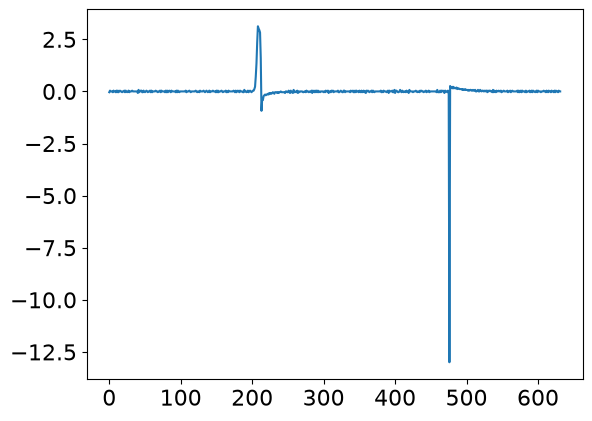

In [6]:
# Plot the difference function
plt.plot(p1_diff)
plt.show()

:::{hint} 🐍 Note
:icon: false
Now create a conditional test as a filter to figure out which values have the largest differences by magnitude. You can also choose to focus on the largest negative difference--figure out which value it is.

You can start with values < -0.1 and incrementally change the threshold to figure out where to stop.
:::

In [7]:
p1_diff[p1_diff<-0.1]

array([ -0.93 ,  -0.373,  -0.409,  -0.224,  -0.186,  -0.149,  -0.186,
        -0.149,  -0.149,  -0.112,  -0.148,  -0.112,  -0.112,  -0.112,
       -12.995])

In [8]:
p1_diff[p1_diff<-0.3]

array([ -0.93 ,  -0.373,  -0.409, -12.995])

In [9]:
p1_diff[p1_diff<-0.5]

array([ -0.93 , -12.995])

In [10]:
# Use the argmin() to find the argument of the minimum value of an array
p1_diff.argmin()

np.int64(476)

In [11]:
# Store the magic number so you don't have to type it out everytime.
x=476

:::{warning} ✏️ Exercise: Verify $p_1$, $p_2$, and $p_3$ on the Graph
:icon: false
Now that you've found the drop, verify that the points we need to calculate are correct. Your plot should contain:

- The original data for one pressure sensor.
- A black dot verifying $p_1$ as index **x**.
- A red dot verifying $p_2$ as index **x+1**.
- A blue dot verifying $p_3$ as the last index **-1**.
- Axes labels.

Your plot should look like this when completed:

<div>
  <center> <img width="500" src="https://github.com/act-cms/adiabatic-expansion-data-analysis/blob/dev/02_adiabatic-expansion/Figures/Adiabatic_DataLabeled.png?raw=True"> </center>
</div>
:::

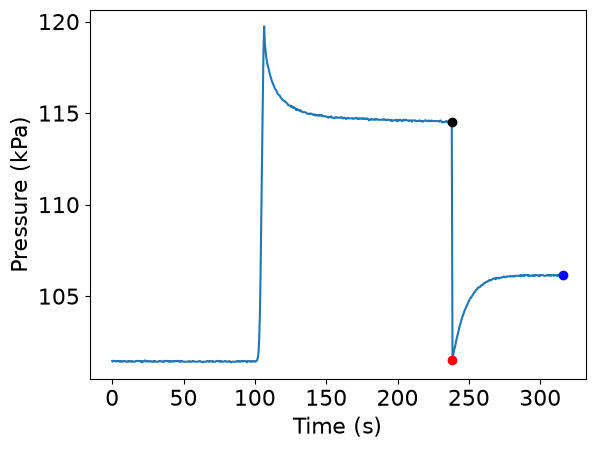

In [12]:
# Plot the data
plt.plot(Ar_Trial1.Time,Ar_Trial1.Pressure1)

# Plot the index to verify if it is indeed the correct value (x) as a black dot
plt.plot(Ar_Trial1.Time.loc[x],Ar_Trial1.Pressure1.loc[x],'ko')

# Then include the next index (x+1) as a red dot
plt.plot(Ar_Trial1.Time.loc[x+1],Ar_Trial1.Pressure1.loc[x+1],'ro')

# And finally the last point as a blue dot
plt.plot(Ar_Trial1.Time.iloc[-1],Ar_Trial1.Pressure1.iloc[-1],'bo')

plt.ylabel('Pressure (kPa)')
plt.xlabel('Time (s)')
plt.show()

In [12]:
# Calculate p1 as the average of the 10 point preceding the drop (x-10:x)
p1=np.average(Ar_Trial1.Pressure1.loc[x-10:x])

# Calculate p2 as the value right after the drop (x+1)
p2=Ar_Trial1.Pressure1.loc[x+1]

# Calculate p3 as the average of the last ten data points collected (.iloc[-10:])
# Remember about the iloc and loc commands to choose data points from a DataFrame\
p3=np.average(Ar_Trial1.Pressure1.iloc[-10:])

print('p1:','%0.3f'%p1, 'kPa')
print('p2:','%0.3f'%p2, 'kPa')
print('p3:','%0.3f'%p3, 'kPa')

p1: 114.528 kPa
p2: 101.533 kPa
p3: 106.139 kPa


## 1.2 Calculate the heat capacity ratio ($\gamma$)

In [ ]:
# @title Exercise: Calculate the heat capacity ratio ($\gamma$)
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> Use your calculated data to calculate the heat capacity ratio (\(\gamma\)) assuming the reaction is

reversible
\begin{equation}
\gamma= \dfrac{ln(p_1)-ln(p_2)}{ln(p_1)-ln(p_3)} \tag{1}
\end{equation}
and irreversible
\begin{equation}
\gamma= \dfrac{\dfrac{p_1}{p_2}-1}{\dfrac{p_1}{p_3}-1} \tag{2}
\end{equation}
</div>


In [13]:
#Reversible
gamma_rev = (np.log(p1)-np.log(p2)) / (np.log(p1) - np.log(p3))
gamma_rev
print(r'γ_rev: ','%0.3f'%gamma_rev)

γ_rev:  1.583


In [14]:
#Irreversible
gamma_irrev = ((p1/p2) - 1) / ((p1/p3) - 1)
gamma_irrev
print(r'γ_irrev: ','%0.3f'%gamma_irrev)

γ_irrev:  1.619


In [ ]:
# @title **Question 3**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
    <p> <strong> Question: </strong> Is there a significant difference between the two methods for calculating \(\gamma\)? </p>
</div>


-----

**ANSWER GOES HERE**

-----

# Part 2. Process the rest of your data



## 2.1 Make your own function

### ***Wouldn’t it be nice if you didn’t have to copy and paste the same code over and over?***

**Python functions** are extremely useful for handling **repetitive tasks** because they let you write a block of code once and reuse it whenever needed. Instead of copying and pasting the same code multiple times, **you can define a function that performs the task and simply call it by name**. This saves time, reduces typing errors, and makes your code cleaner and easier to maintain.

In [ ]:
# @title Exercise
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
<ul>
  <li> Create a function to import your data and calculate the heat capacities based on your code.</li>
  <li> Create your function to replicate the results for the trial you used in part 1. Then use the function for the other gases and trials.</li>
  <li> Combine the different aspects using your data to calculate the values you want with ease. </li>
  <ul>
  <li> You can include as many variables as you need.</li>
  <li> This way, you don't have to repeat the same calculations and change variables every single time you introduce a new dataset.</li>
  <li> Include plots as done in the exercise in Part 1.1 to verify the code is working correctly.</li>
  <li> Calculate the respective pressures and heat capacities.</li>

  </ul>
</ul>
</div>


In [15]:
def calculate_gamma(data,col='Pressure1'):
  p1_diff=np.diff(data[col])
  x1=p1_diff.argmin()

  # Plot the data
  plt.plot(data.Time,data[col])

  # Plot the index to verify if it is indeed the correct value (x) as a black dot
  plt.plot(data.Time.loc[x1],data[col].loc[x1],'ko')

  # Then include the next index (x+1) as a red dot
  plt.plot(data.Time.loc[x1+1],data[col].loc[x1+1],'ro')

  # And finally the last point as a blue dot
  plt.plot(data.Time.iloc[-1],data[col].iloc[-1],'bo')

  plt.ylabel('Pressure (kPa)')
  plt.xlabel('Time (s)')
  plt.show()

  # Calculate p1
  p1=np.average(data[col].loc[x1-10:x1])

  # Calculate p2
  p2=data[col].loc[x1+1]

  # Calculate p3
  p3=np.average(data[col].iloc[-10:])

  # Print the pressures
  print('p1:',p1.round(3))
  print('p2:',p2.round(3))
  print('p3:',p3.round(3))

  # Calculate the heat capacities
  gamma_rev = (np.log(p1)-np.log(p2)) / (np.log(p1) - np.log(p3))
  gamma_irrev = ((p1/p2) - 1) / ((p1/p3) - 1)

  # Print the heat capacities
  print(r'γ_rev:',gamma_rev.round(3))
  print(r'γ_irrev:',gamma_irrev.round(3))

In [ ]:
# @title Note
%%html

 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <b> How should you make a function to automate a task you've already done once? </b>

<ul>
  <li> You can copy and paste your code from either section above that completed the task for one set of data.</li>
  <li> Find the variables that you know you will need to replace between runs to create the function.</li>
  <li> Follow the Python notation to create a function of multiple variables.
    The goal of this Python function is to be able to repeat the task for whatever set of data you want it to.</li>
</ul>
This will allow you to create a function to automate a task and not have to worry about copying multiple blocks of code depending on your data.
</div>

## 2.2 Try out your function

Calculate the heat capacity ratios for $Ar$, $N_2$, and $C_3H_8$ for all your trials

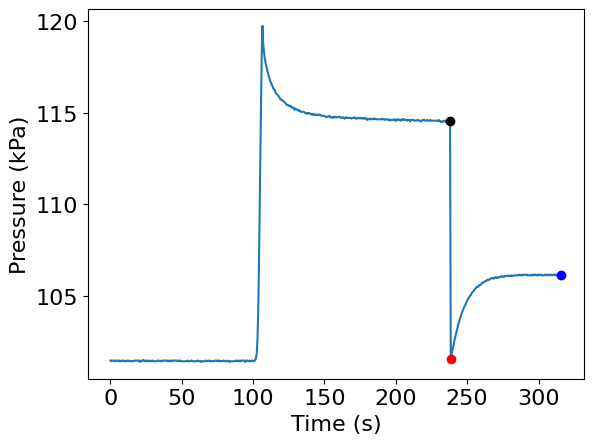

p1: 114.528
p2: 101.533
p3: 106.139
γ_rev: 1.583
γ_irrev: 1.619


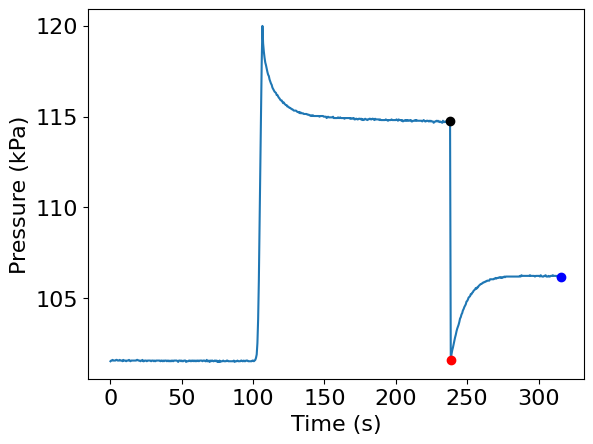

p1: 114.722
p2: 101.623
p3: 106.236
γ_rev: 1.578
γ_irrev: 1.614


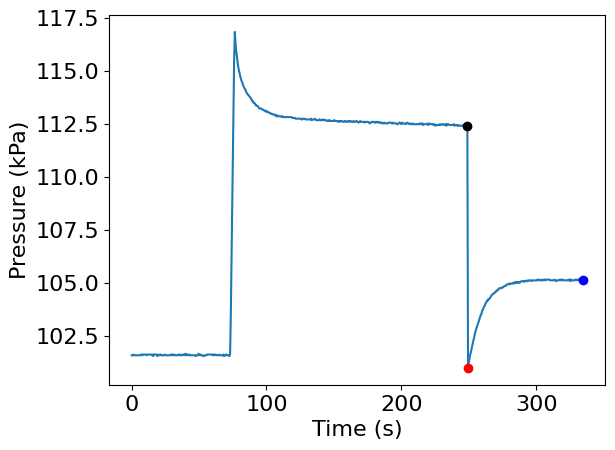

p1: 112.409
p2: 100.974
p3: 105.126
γ_rev: 1.602
γ_irrev: 1.635


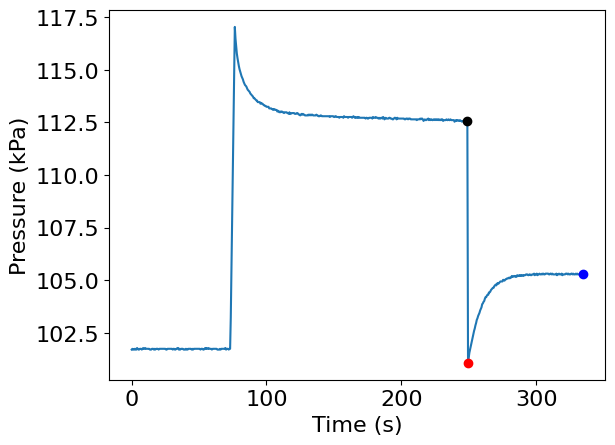

p1: 112.577
p2: 101.064
p3: 105.279
γ_rev: 1.61
γ_irrev: 1.643


In [16]:
# Ar

calculate_gamma(Ar_Trial1,'Pressure1')
calculate_gamma(Ar_Trial1,'Pressure2')
calculate_gamma(Ar_Trial2,'Pressure1')
calculate_gamma(Ar_Trial2,'Pressure2')

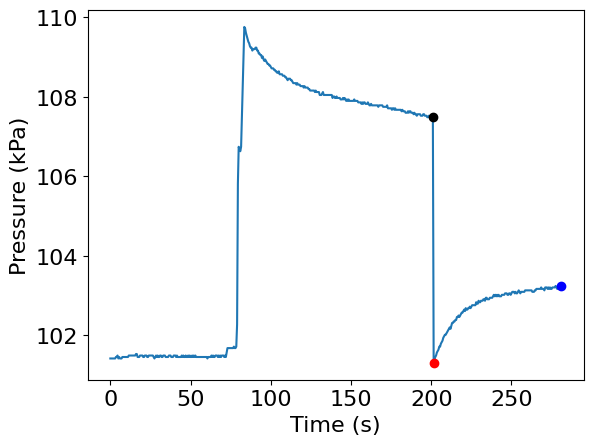

p1: 107.495
p2: 101.304
p3: 103.203
γ_rev: 1.456
γ_irrev: 1.47


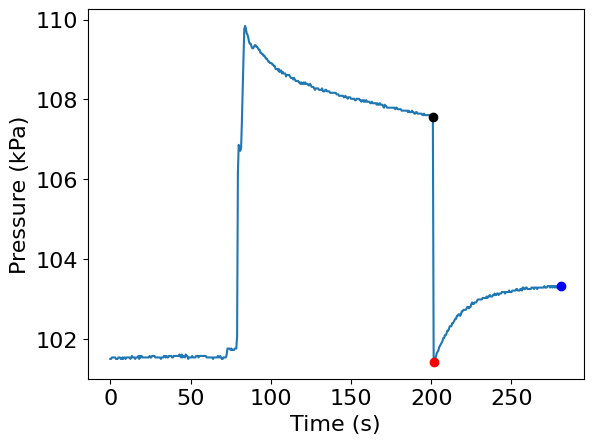

p1: 107.6
p2: 101.426
p3: 103.321
γ_rev: 1.456
γ_irrev: 1.47


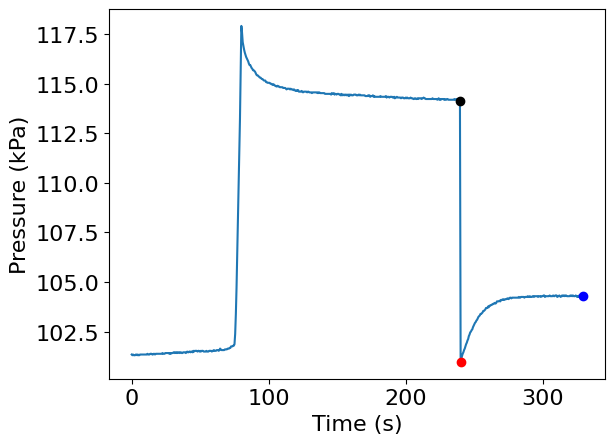

p1: 114.203
p2: 100.974
p3: 104.285
γ_rev: 1.355
γ_irrev: 1.377


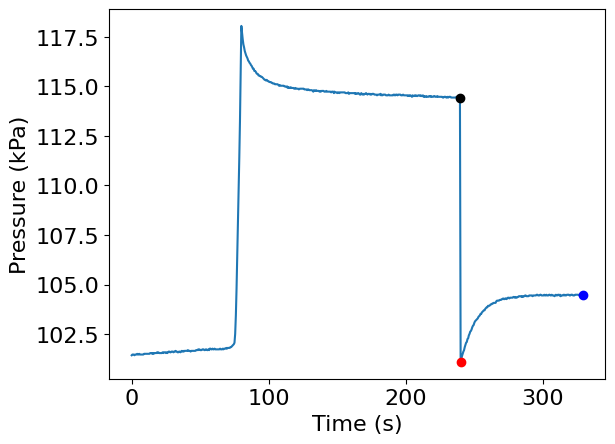

p1: 114.431
p2: 101.102
p3: 104.475
γ_rev: 1.361
γ_irrev: 1.383


In [17]:
# N2
calculate_gamma(N2_Trial1,'Pressure1')
calculate_gamma(N2_Trial1,'Pressure2')
calculate_gamma(N2_Trial2,'Pressure1')
calculate_gamma(N2_Trial2,'Pressure2')

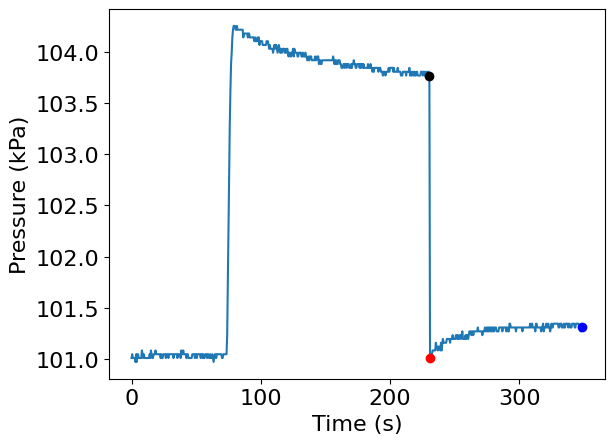

p1: 103.787
p2: 101.012
p3: 101.325
γ_rev: 1.129
γ_irrev: 1.13


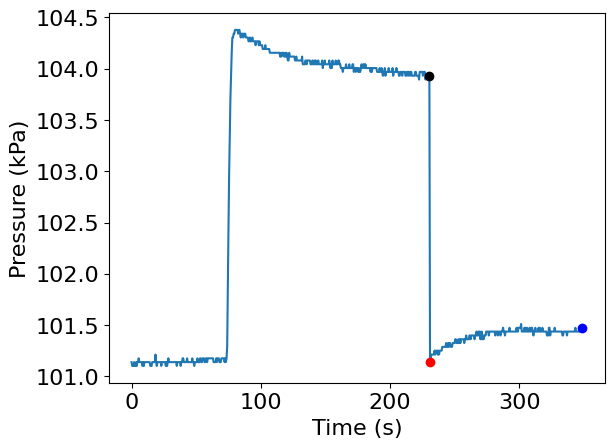

p1: 103.935
p2: 101.139
p3: 101.444
γ_rev: 1.124
γ_irrev: 1.126


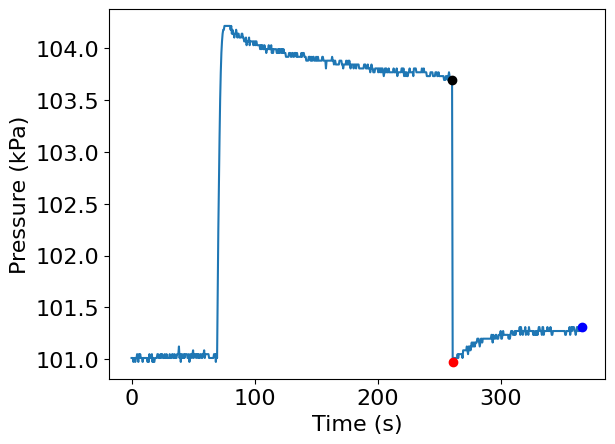

p1: 103.717
p2: 100.974
p3: 101.291
γ_rev: 1.132
γ_irrev: 1.134


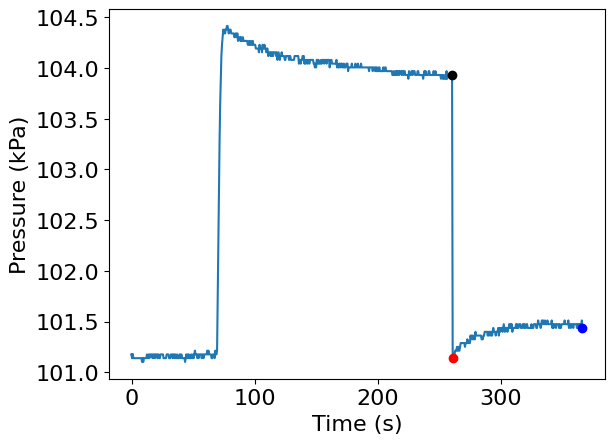

p1: 103.928
p2: 101.139
p3: 101.463
γ_rev: 1.133
γ_irrev: 1.135


In [18]:
# C3H8

calculate_gamma(C3H8_Trial1,'Pressure1')
calculate_gamma(C3H8_Trial1,'Pressure2')
calculate_gamma(C3H8_Trial2,'Pressure1')
calculate_gamma(C3H8_Trial2,'Pressure2')

# Part 3. Calculate the heat capacities using computational chemistry

In physical chemistry, we often want to connect **molecular structure** with **observable properties** like reaction energies, spectra, or heat capacities. Electronic structure programs such as **ORCA**, **Gaussian**, or **PSI4** do this by numerically solving the **Schrödinger equation** for molecules.

- **Inputs:**  
  - Atom types
  - XYZ coordinates
  - choice of quantum mechanical method (e.g., Hartree–Fock, DFT)
  - basis set (e.g., cc-pVTZ, def2-TZVP).

- **Outputs:**  
  - Optimized molecular geometries  
  - Electronic energies  
  - Molecular orbitals  
  - Vibrational frequencies and thermodynamic properties

The program uses quantum mechanics to determine the electronic energy and force constants of a molecule. From the force constants (via vibrational frequencies), we apply **statistical thermodynamics** to predict macroscopic properties like $C_p$, $C_v$, $\Delta H$, $\Delta S$, and $\Delta G$.  

---
Heat Capacity Calculations in PSI4

1. **Frequency analysis**  
   - PSI4 optimizes the geometry and computes harmonic vibrational frequencies ($\nu_i$), rotational constants, and the electronic energy.

2. **Calculate thermodynamic partition functions**  
   - Uses the rigid rotor harmonic oscillator (RRHO) model to compute translational, rotational, vibrational, and (optionally) electronic partition functions from the frequency data.

3. **Compute energy and heat capacity**
$$C_v = \left( \frac{\partial U}{\partial T} \right)_V$$
$$C_p = C_v + R$$
   - Internal energy components:
     - Translational & rotational → constant (classical)
     - Vibrational → temperature-dependent (mode by mode):
     $$
     C_{v,\text{vib}} = R \sum_i \left( \frac{h \nu_i}{k_B T} \right)^2 \frac{e^{h\nu_i/(k_B T)}}{(e^{h\nu_i/(k_B T)} - 1)^2}
     $$


## 3.1 Compute $\gamma$ for $Ar$ and $N_2$

In [ ]:
# @title Exercise: Analyze the output files for $Ar$ and $N_2$
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>

<ul>
<li> Open the PSI4 output files (optfreq_output_Ar.out, optfreq_output_N2.out)
  from the pre-lab assignment in a text-based editor (Notepad or Notepad++). </li>
<li> Scroll through the output file and make a note of where to find the information you need (Cp and Cv). </li>
<li> Find and record any unique phrases in the line that can be used in a text-based search to extract these values. </li>
</div>

In [19]:
# Visualize the file in Python
with open('optfreq_output_Ar.out') as f:
  lines = f.readlines()

# Lines is a list where each line is a element in the list
lines

['\n',
 '         ----------------------------------------------------------\n',
 '                                   FINDIF\n',
 '                     R. A. King and Jonathon Misiewicz\n',
 '         ----------------------------------------------------------\n',
 '\n',
 '  Using finite-differences of gradients to determine vibrational frequencies and \n',
 '  normal modes. Resulting frequencies are only valid at stationary points.\n',
 '    Generating geometries for use with 3-point formula.\n',
 '    Displacement size will be 5.00e-03.\n',
 '    Number of atoms is 1.\n',
 '    Number of irreps is 8.\n',
 '    Number of SALCs is 0.\n',
 '    Translations projected? 1. Rotations projected? 0.\n',
 '    Index of SALCs per irrep:\n',
 '      1 : \n',
 '      2 : \n',
 '      3 : \n',
 '      4 : \n',
 '      5 : \n',
 '      6 : \n',
 '      7 : \n',
 '      8 : \n',
 '    Number of SALCs per irrep:\n',
 '      Irrep 1: 0\n',
 '      Irrep 2: 0\n',
 '      Irrep 3: 0\n',
 '      Irrep 4:

In [20]:
# Visualize the file in Python
with open('optfreq_output_N2.out') as g:
  lines2 = g.readlines()

# Lines is a list where each line is a element in the list
lines2

['\n',
 'Scratch directory: /tmp/\n',
 'gradient() will perform analytic gradient computation.\n',
 '   => Libint2 <=\n',
 '\n',
 '    Primary   basis highest AM E, G, H:  6, 6, 3\n',
 '    Auxiliary basis highest AM E, G, H:  7, 7, 4\n',
 '    Onebody   basis highest AM E, G, H:  -, -, -\n',
 '    Solid Harmonics ordering:            Gaussian\n',
 '\n',
 '*** tstart() called on 4f125c5b2ebd\n',
 '*** at Fri Aug  1 19:45:25 2025\n',
 '\n',
 '   => Loading Basis Set <=\n',
 '\n',
 '    Name: CC-PVTZ\n',
 '    Role: ORBITAL\n',
 '    Keyword: BASIS\n',
 '    atoms 1-2 entry N          line   224 file /usr/local/envs/psi4_env/share/psi4/basis/cc-pvtz.gbs \n',
 '\n',
 '\n',
 '         ---------------------------------------------------------\n',
 '                                   SCF\n',
 '               by Justin Turney, Rob Parrish, Andy Simmonett\n',
 '                          and Daniel G. A. Smith\n',
 '                              RKS Reference\n',
 '                        1 Thr

In [ ]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation3.json',"lab-3-1")

<IPython.core.display.Javascript object>

In [21]:
with open('optfreq_output_Ar.out') as f:
  lines = f.readlines()

# Find the lines containing 'Total Cp' and 'Total Cv'
for line in lines:
    if 'Total Cp' in line:
        print(line)
    elif 'Total Cv' in line:
        print(line)

  Total Cv                                   2.981 [cal/(mol K)]       12.472 [J/(mol K)]       0.00475022 [mEh/K]

  Total Cp                                   4.968 [cal/(mol K)]       20.786 [J/(mol K)]       0.00791703 [mEh/K]



In [22]:
with open('optfreq_output_N2.out') as f:
  lines = f.readlines()

# Find the lines containing 'Total Cp' and 'Total Cv'
for line in lines:
    if 'Total Cp' in line:
        print(line)
    elif 'Total Cv' in line:
        print(line)

  Total Cv                                   4.970 [cal/(mol K)]       20.794 [J/(mol K)]       0.00791987 [mEh/K]

  Total Cp                                   6.957 [cal/(mol K)]       29.108 [J/(mol K)]       0.01108669 [mEh/K]



<font color='red'> **Note to instructors: **
<font color='red'> If your students are familiar with bash, they can use the grep command to extract the correct phrases

```python
# An alternative to find the phrase using grep within bash
%%bash
grep 'Total Cv' optfreq_output_Ar.out
grep 'Total Cp' optfreq_output_Ar.out
```

```
Output: (spaced scaled to fit in the cell)
Total Cv  2.981 [cal/(mol K)]  12.472 [J/(mol K)]  0.00475022 [mEh/K]
Total Cp  4.968 [cal/(mol K)]  20.786 [J/(mol K)]  0.00791703 [mEh/K]
  ```

In [23]:
# Put in the values manually for Ar and calculate the heat capacity ratio
cp = 20.786
cv = 12.472
print(f"Cp = {cp} J/mol·K")
print(f"Cv = {cv} J/mol·K")
print(f"gamma = {round(cp/cv, 3)}")

Cp = 20.786 J/mol·K
Cv = 12.472 J/mol·K
gamma = 1.667


In [24]:
# Put in the values manually for N2 and calculate the heat capacity ratio
cp = 29.108
cv = 20.794
print(f"Cp = {cp} J/mol·K")
print(f"Cv = {cv} J/mol·K")
print(f"gamma = {round(cp/cv, 3)}")

Cp = 29.108 J/mol·K
Cv = 20.794 J/mol·K
gamma = 1.4


## 3.2 Compute $\gamma$ for $C_3H_8$

In [ ]:
# @title Exercise: Extract $C_p$ and $C_v$ for $C_3H_8$
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>

The ZIP folder that was loaded into the Colab environment contains <b>342 different 3D conformations of propane</b>.
<p>Each file represents a single geometry of the propane molecule that differs slightly in:</p>
<ul>
<li><b>The C–C–C bond angle</b> – how wide or narrow the central carbon angle is. Scanned from 90\(^\circ\) to 170\(^\circ\) in ~5\(^\circ\) intervals (18 steps)</li>
<li><b>The C–C–C–H dihedral angle</b> – how one of the hydrogens is twisted around the carbon–carbon bond. Scanned from 0\(^\circ\) to 180\(^\circ\) in 10\(^\circ\) increments (19 steps)</li>
</ul>

Each conformation is stored as an individual output file containing atomic coordinates and the calculated thermodynamic properties at 298 K and 1 atm.
<ul>
<li>You can read them into Python, visualize them, or calculate the relative energies to see which shapes are more stable.
<li>By scanning through all 342 files, you can make a <em>conformational energy surface</em> showing how stability depends on both the bond angle and the twist around the C–C bond.
</ul>

You will need to do the following with the 342 output files:
<ul>
  <li> Identify the phrases within the output files that correspond to \(C_p\) and \(C_v\)
  <li> Fill in the blanks in the provided <code>extract_cp_cv</code> function to be able to extract \(C_p\) and \(C_v\) for all 342 output files for propane </li>

</ul>
</div>


#### What is a dihedral angle?
<p> You already know <em>anti</em> and <em>gauche</em> from butane: these terms describe how groups are arranged when you rotate around a C–C bond.
  In propane, even though there’s only one C–C bond to rotate around, we can still describe different positions of the hydrogens relative
  to each other using a <b>dihedral angle</b>. </p>

<p> A <b>dihedral angle</b> is simply the angle between two planes.
Here, it tells us how one hydrogen is oriented relative to the rest of the molecule as we twist around the C–C bond.</p>

The dihedral angle is the angle between two planes — here it’s defined by four atoms ($C_8-C_4-C_1-H_3$) in propane.

<div>
  <center> <img height="300" src="https://github.com/prajay-patel/CHE-3131/blob/main/Rotation-3-Thermodynamics/Figures/propane_dihedral.jpg?raw=True"> </center>
</div>

In [ ]:
# @title Question 4
%%html

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">

<p> <b> Why are we varying the dihedral angles? </b>
</div>

---

**ANSWER GOES HERE**

---

In [ ]:
# @title Note
%%html

 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <b> How should we think about a dihedral angle rotation? </b>

<ul>
  <li> Imagine holding one CH\(_3\) group fixed.</li>
  <li> Rotate the other CH\(_3\) group around the C–C bond, which changes the <b>dihedral angle</b>.</li>
  <li> Adjusting the central C–C–C bond angle at the same time gives a full map of how the molecule can bend and twist.</li>
</ul>
</div>

In [25]:
# @title Unzip data and sort contents
# @markdown Expand this cell to see how the code works. The first and last five files in the list are shown.

# Unzip the folder and put the data into a folder called C3H8_PSI4_data
!unzip -q C3H8_PSI4_data.zip -d C3H8_PSI4_data

propane_outs=sorted(glob('/content/C3H8_PSI4_data/outputs/*.out'))

#Using print statements to show the first and last five files in the list
print('[','\n'.join(propane_outs[:5]))
print('...')
print('\n'.join(propane_outs[-5:]),']')


[ /content/C3H8_PSI4_data/outputs/propane.001.out
/content/C3H8_PSI4_data/outputs/propane.002.out
/content/C3H8_PSI4_data/outputs/propane.003.out
/content/C3H8_PSI4_data/outputs/propane.004.out
/content/C3H8_PSI4_data/outputs/propane.005.out
...
/content/C3H8_PSI4_data/outputs/propane.338.out
/content/C3H8_PSI4_data/outputs/propane.339.out
/content/C3H8_PSI4_data/outputs/propane.340.out
/content/C3H8_PSI4_data/outputs/propane.341.out
/content/C3H8_PSI4_data/outputs/propane.342.out ]


In [ ]:
# @title Exercise: Extract $C_p$ and $C_v$ for propane
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> Fill in the blanks in this function
to be able to extract \(C_p\) and \(C_v\) for all 342 output files for propane
</div>


In [26]:
def extract_cp_cv(filename):
    cp = None
    cv = None
    with open(filename) as f:
        # Loop through each line
        for line in f:
            # Check if the phrase 'Total Cp' is in the line
            if 'Total Cp' in line:
                # Extract the number from the string that contains Total Cp
                cp = float(line.split()[5].strip())
            # Check if the phrase 'Total Cv' is in the line if 'Total Cp' is not in the line
            elif 'Total Cv' in line:
                # Extract the number from the string that contains Total Cp
                cv = float(line.split()[5].strip())
    return cp, cv

<font color='red'> **Note to Instructors:**
<font color='red'> The code here using the more reliable tqdm package can be used in place of the more colorful progress bar shown in the main code. This more colorful progress bar may have some bugs based on the interface.

```python
#Student Version
def extract_cp_cv(filename):
    cp = None
    cv = None
    with open(filename) as f:
        # Loop through each line
        for line in f:
            # Check if 'phrase1' is in the line
            if 'phrase1' in line:
                # Extract the value by splitting the string
                cp =
            # Check if 'phrase3' is in the line
            elif 'phrase2' in line:
                # Extract the value by splitting the string
                cv =
    # Return the values of Cp and Cv
    return cp, cv

# Extract the Cp and Cv values for propane (tqdm)

# Define blank lists for Cp, Cv, and gamma -- we will use these to store all the extracted values
C3H8_Cp=[]
C3H8_Cv=[]
C3H8_gamma=[]

for i in trange(len(propane_outs)):
  cp, cv = extract_cp_cv(propane_outs[i])

  # Calculate the heat capacities -- store in a list
  C3H8_Cp.append(cp)
  C3H8_Cv.append(cv)
  C3H8_gamma.append(cp/cv)

# Convert to NumPy array for vectorized math operations
C3H8_Cp=np.array(C3H8_Cp)
C3H8_Cv=np.array(C3H8_Cv)
C3H8_gamma=np.array(C3H8_gamma)
```

In [ ]:
# Practice cell to test code


In [27]:
# Define blank lists for Cp, Cv, and gamma
# we will use these to store all the extracted values
C3H8_Cp = []
C3H8_Cv = []
C3H8_gamma = []

# Creates a multicolored progress bar
with Progress(
    TextColumn("[bold]Extracting Cp, Cv for Propane[/]"),
    BarColumn(bar_width=None, complete_style="bold white"),
    TextColumn("[cyan]{task.completed}/{task.total}"),
    TimeElapsedColumn(),
) as progress:

    task = progress.add_task("processing", total=len(propane_outs))

    # The actual code to compute the heat capacities for all 342 files
    for i in range(len(propane_outs)):
        cp, cv = extract_cp_cv(propane_outs[i])
        C3H8_Cp.append(cp)
        C3H8_Cv.append(cv)
        C3H8_gamma.append(cp / cv)

        # Sample color from colormap
        color_rgb = cmap(i / len(propane_outs))  # returns RGBA tuple
        hex_color = mcolors.rgb2hex(color_rgb[:3])

        # Dynamically update the bar style using that color
        progress.columns[1].complete_style = Style(color=hex_color)
        progress.update(task, advance=1)

# Convert to NumPy array for vectorized math operations
C3H8_Cp = np.array(C3H8_Cp)
C3H8_Cv = np.array(C3H8_Cv)
C3H8_gamma = np.array(C3H8_gamma)

# Show that the extraction is complete if the progress bar does not indicate it
# due to compatability
print("Extraction of "+str(len(C3H8_Cp))+" files complete.")

Output()

Extraction of 342 files complete.


In [28]:
# Showing the final extracted values for propane conformations
C3H8_calc_data=pd.DataFrame([C3H8_Cp,C3H8_Cv,C3H8_gamma.round(3)],index=['Cp','Cv','Gamma'],columns=np.arange(1,343,1)).T
C3H8_calc_data

,Cp,Cv,Gamma
1,77.578,69.264,1.120
2,77.418,69.104,1.120
3,77.349,69.035,1.120
4,69.114,60.800,1.137
5,68.709,60.394,1.138
...,...,...,...
338,80.667,72.353,1.115
339,80.987,72.673,1.114
340,73.017,64.703,1.128
341,73.125,64.810,1.128


In [29]:
# Calculate the average of Cp, Cv, and Gamma to 3 decimal places
C3H8_calc_data.mean(axis=0).round(3)

,0
Cp,72.210
Cv,63.896
Gamma,1.131


In [30]:
print(r'γ for propane:', '%0.2f'%(C3H8_calc_data['Gamma'].mean(axis=0))\
      +' ± '+'%0.2f'%(C3H8_calc_data['Gamma'].std(ddof=1)))

γ for propane: 1.13 ± 0.01


<font color='red'> **Note to instructors:**
<font color='red'> For students familiar with bash and want to give it a shot -- a bash environment can be used to grep (get the regular expression) the various heat capacity values from the respective files. Using bash is needed for computational chemistry workflows for navigating terminal interfaces and running submission and quick analysis scripts.

```python
%%bash

echo "Cp, Cv, Gamma" # Print header

for file in /content/C3H8_PSI4_data/outputs/*.out
do
    cp=$(grep 'Total Cp' "$file" | awk '{print $6}')
    cv=$(grep 'Total Cv' "$file" | awk '{print $6}')
    gamma=$(awk "BEGIN { printf \"%.3f\", $cp / $cv }")
    echo "$cp, $cv, $gamma"
done
```

## 3.3 Combine the answers into a single dataframe

Use the calculations of the heat capacities from the electronic structure calculations to determine the heat capacities.

In [31]:
# Create numpy arrays or lists of Cp and Cv to calculate gamma (Cp/Cv)
# Each list should contain the values for Ar, N2, and propane in that order
Cp=[20.786,29.108,72.210]
Cv=[12.472,20.794,63.896]
Gamma=[1.667,1.400,1.131]

# Creates the dataframe to display the calculated values accordingly
pd.DataFrame({'Cp':Cp,'Cv':Cv,'Gamma':Gamma},index=['Argon','Nitrogen','Propane'])

,Cp,Cv,Gamma
Argon,20.786,12.472,1.667
Nitrogen,29.108,20.794,1.400
Propane,72.210,63.896,1.131


# Part 4. Compare Experiment and Theory

In [ ]:
# @title Exercise: Compare Experiment and Theory
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: How close are we? </strong>
<ul>
  <li>
Compare the averages from the experimental trials to the computed values by creating a
DataFrame that displays the computed and experimental values.   </li>
  <li>Compute the averages of the experimental heat capacity ratios determined in Part 1
and compare to the computed heat capacities determined in Part 3.  </li>
</div>


In [32]:
Gamma_Comp=[1.667,1.400,1.131]
Gamma_Rev_Exp=[1.593,1.407,1.130]
Gamma_Irrev_Exp=[1.628,1.425,1.131]

# Creates the dataframe to display the calculated values accordingly
pd.DataFrame({'Gamma Computed':Gamma_Comp,'Gamma Rev Exp':Gamma_Rev_Exp,\
              'Gamma Irrev Exp':Gamma_Irrev_Exp},index=['Argon','Nitrogen','Propane'])

,Gamma Computed,Gamma Rev Exp,Gamma Irrev Exp
Argon,1.667,1.593,1.628
Nitrogen,1.400,1.407,1.425
Propane,1.131,1.130,1.131


In [ ]:
# @title Key Points
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.green-note {
    color: #155724; /* Dark green for text */
    background-color: #d4edda; /* Light green background */
    border-left: 5px solid #28a745; /* Bright green border */
    padding: 0.5em;
    font-size: 1.25em; /* Consistent with text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean and modern font */
}
div.green-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.green-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="green-note">
    <strong>Key Points:</strong>
    <ul>
      <li> Use data slicing to find relevant information in an array</li>
      <li> Extract relevant text from a text-based file</li>
      <li> Compute heat capacities using experimental and computational techniques</li>
      <li> Use Python functions to save time in doing repetitive tasks</li>
</div>